In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import ot
import random
from RobustPartialGW import *

# Simple Experiment

This experiment will illustrate the basic behavior of the robust GW metric. We'll create a dataset consisting of:
- Several noisy circles, with varying amounts of outlier noise contamination
- Several noisy ellipses, with varying amounts of outlier noise contamination, maybe add some random rotations

From this dataset, we'll do two things:
- Compute mPGW distances from one circle to all other datasets, for many choices of mass conservation $1-\delta$. Plot these distances and look at intersections with the $k*\delta$ line. We should see better clustering of the intersection points.
- Compute all pairwise robust mPGW distances, look at distance matrices and MDS plots, hopefully see more structure in the mPGW version when compared to GW distance.

### Intersection Plot

In [2]:
num_shapes = 5
num_points = 100
labels = [0]*num_shapes + [1]*num_shapes
SNR_range = [0.05,1]
circle_radius = 2
ellipse_radii = [1,2]
outlier_bounds = [-5,5]
noise_level = 0.1


SNRs = np.linspace(SNR_range[0],SNR_range[1],num_shapes)
shapes = []

thetas = np.linspace(0,2*np.pi,num_points)
circle_points = circle_radius*np.array([np.cos(thetas),np.sin(thetas)])
ellipse_points = np.array([ellipse_radii[0]*np.cos(thetas),ellipse_radii[1]*np.sin(thetas)])

for SNR in SNRs:
    # Circles
    perturbed_points = (circle_points + np.random.normal(0, noise_level, num_points)).T
    num_random_points = int(SNR*num_points)
    if num_random_points == 0:
        noisy_points = perturbed_points
    else:
        random_points = np.random.uniform(outlier_bounds[0], outlier_bounds[1], (num_random_points, 2))
        noisy_points = np.vstack((perturbed_points, random_points))
    shapes.append(noisy_points)
    
for SNR in SNRs:
    # Ellipses
    perturbed_points = (ellipse_points + np.random.normal(0, noise_level, num_points)).T
    ## Add a rotation
    angle = np.random.uniform(0, 2 * np.pi)

    # Create the 2D rotation matrix
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],[np.sin(angle),  np.cos(angle)]])
    perturbed_points = perturbed_points@rotation_matrix
    
    
    num_random_points = int(SNR*num_points)
    if num_random_points == 0:
        noisy_points = perturbed_points
    else:
        random_points = np.random.uniform(outlier_bounds[0], outlier_bounds[1], (num_random_points, 2))
        noisy_points = np.vstack((perturbed_points, random_points))
    shapes.append(noisy_points)

/var/folders/pl/dmrd__g90wl2vvwjw6nshkn80000gp/T/ipykernel_91429/3172715189.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')
/var/folders/pl/dmrd__g90wl2vvwjw6nshkn80000gp/T/ipykernel_91429/3172715189.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Reds')


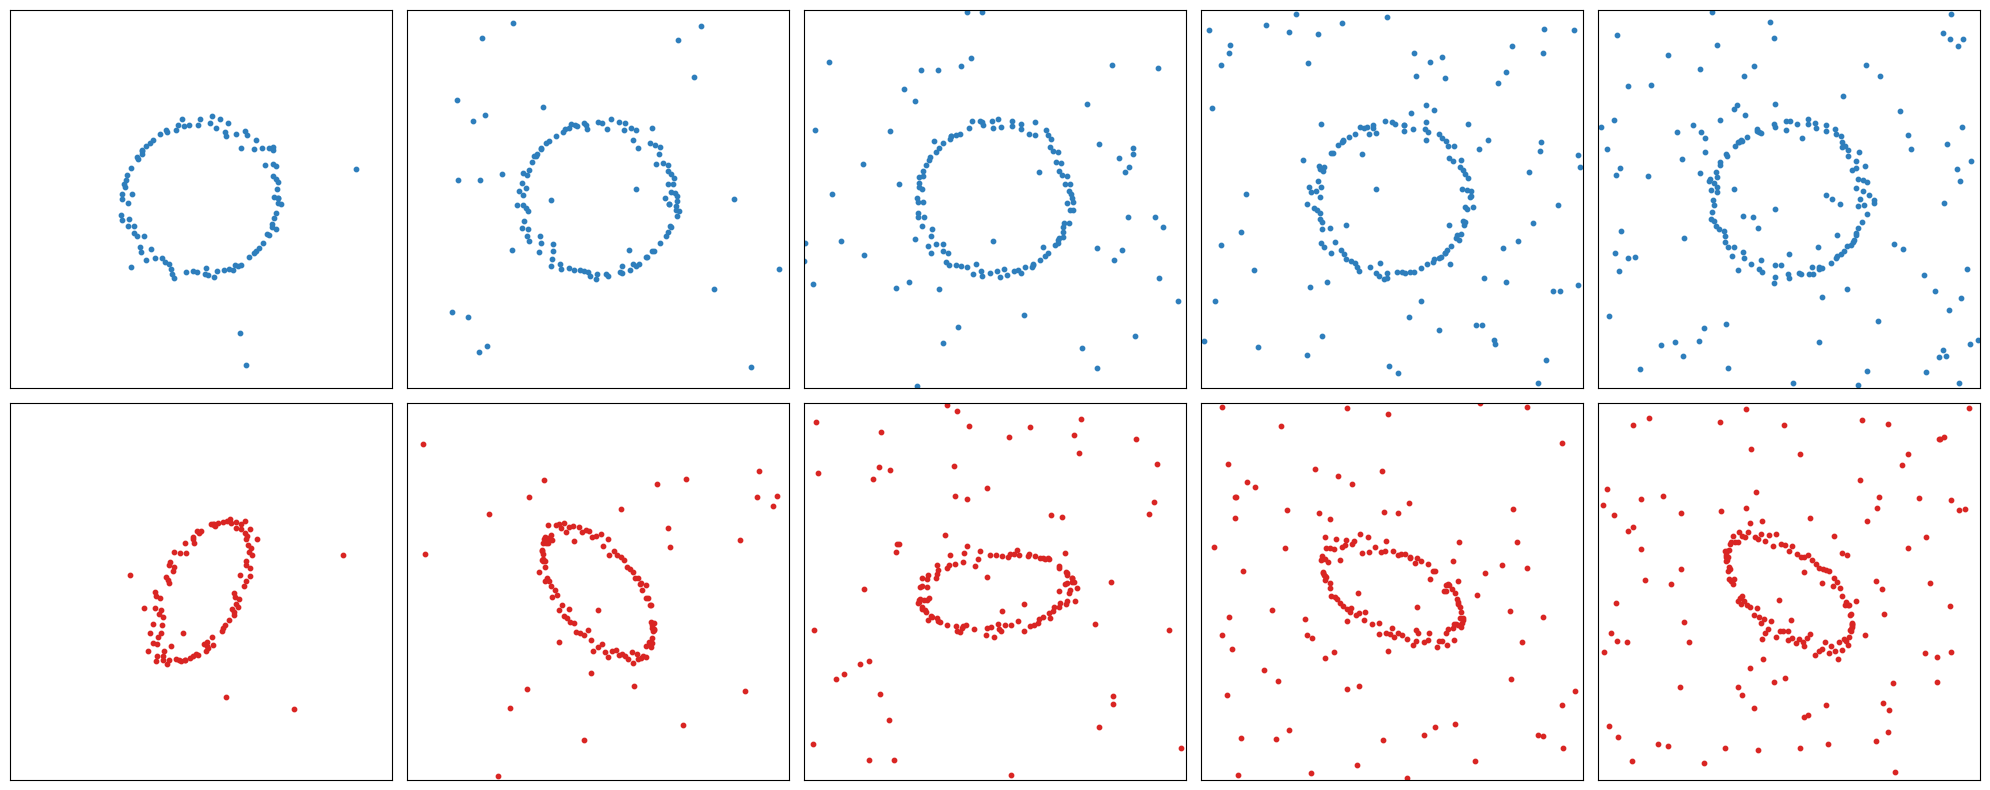

In [3]:
plt.figure(figsize=(int(5 * 4), 8))

for index in range(5):
    color_start = 0.7
    color_end = 0.7
    colormap = cm.get_cmap('Blues')
    color_fraction = color_start + (color_end - color_start) * (index / (num_shapes - 1))

    # First subplot
    plt.subplot(2, 5, index + 1)
    plt.scatter(shapes[index][:, 0], shapes[index][:, 1], color=colormap(color_fraction), s=10)
    plt.xlim([-5, 5])
    plt.ylim([-5, 5])
    plt.xticks([])  # Remove x-axis ticks and labels
    plt.yticks([])  # Remove y-axis ticks and labels

    colormap = cm.get_cmap('Reds')
    color_fraction = color_start + (color_end - color_start) * (index / (num_shapes - 1))
    # Second subplot
    plt.subplot(2, 5, 5 + index + 1)
    plt.scatter(shapes[index + 5][:, 0], shapes[index + 5][:, 1], color=colormap(color_fraction), s=10)
    plt.xlim([-5, 5])
    plt.ylim([-5, 5])
    plt.xticks([])  # Remove x-axis ticks and labels
    plt.yticks([])  # Remove y-axis ticks and labels

# Adjust layout to make it tighter
plt.tight_layout()

plt.show()


Get metric measure space data from the shapes:

In [4]:
from sklearn.metrics.pairwise import euclidean_distances

dist_mats = [euclidean_distances(x) for x in shapes]

radius = 2

distributions = [density_based_weighting(dist_mat,radius = radius) for dist_mat in dist_mats]
# distributions = [ot.unif(len(dist_mat)) for dist_mat in dist_mats]

In [5]:
k = 1
masses = np.linspace(0.000001,0.3,20)

template = (circle_points + np.random.normal(0, noise_level, num_points)).T
template_dist_mat = euclidean_distances(template)
template_distribution = density_based_weighting(template_dist_mat, radius = radius)

list_of_arrays = []

for j in range(len(shapes)):
    dists = []
    for mass in masses:
        dist, T = ot.gromov.partial_gromov_wasserstein2(template_dist_mat,dist_mats[j],template_distribution,distributions[j],m=1-mass,log=True)
        dists.append(dist)
    list_of_arrays.append(dists)

<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/var/folders/pl/dmrd__g90wl2vvwjw6nshkn80000gp/T/ipykernel_91429/4235055900.py:28: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel("Mass Parameter $\delta$",fontsize = 20)
/var/folders/pl/dmrd__g90wl2vvwjw6nshkn80000gp/T/ipykernel_91429/4235055900.py:29: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathrm{mPGW}_{2,1-\delta}$",fontsize = 20)
/var/folders/pl/dmrd__g90wl2vvwjw6nshkn80000gp/T/ipykernel_91429/4235055900.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Blues')
/var/folders/pl/dmrd__g90wl2vvwjw6nshkn80000gp/T/ipykernel_91429/4235055900.py:16: Matplotl

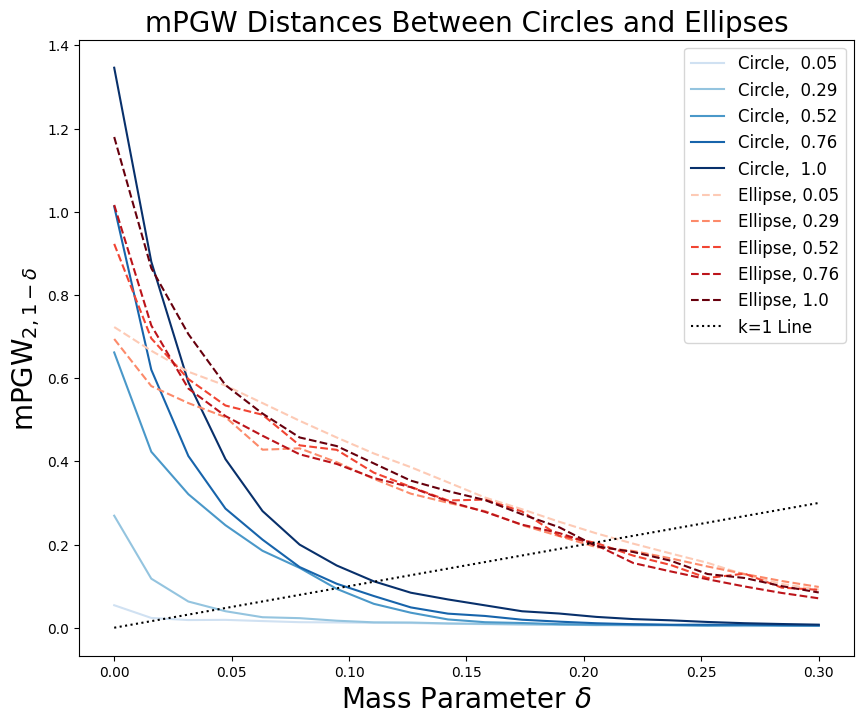

In [6]:
from matplotlib import cm

color_start = 0.2
color_end = 1.0
colormap = cm.get_cmap('Blues')

# Create the plot
plt.figure(figsize=(10, 8))
for i in range(num_shapes):
    array = list_of_arrays[i]
    color_fraction = color_start + (color_end - color_start) * (i / (num_shapes - 1))
    plt.plot(masses,array, color=colormap(color_fraction), label=f'Circle,  {np.round(SNRs[i],2)}')
    
color_start = 0.2
color_end = 1.0
colormap = cm.get_cmap('Reds')

# Create the plot
for i in range(num_shapes):
    array = list_of_arrays[i+num_shapes]
    color_fraction = color_start + (color_end - color_start) * (i / (num_shapes - 1))
    plt.plot(masses,array,'--', color=colormap(color_fraction), label=f'Ellipse, {np.round(SNRs[i],2)}')

plt.plot(masses,[k*mass for mass in masses],':',color = 'black',label=f'k={k} Line')

# Customize the plot
plt.title("mPGW Distances Between Circles and Ellipses",fontsize = 20)
plt.xlabel("Mass Parameter $\delta$",fontsize = 20)
plt.ylabel("$\mathrm{mPGW}_{2,1-\delta}$",fontsize = 20)
plt.legend(loc='upper right', fontsize='large')  # Optional: Add legend
plt.show()

### Matching Illustration

Here, we'll show sample matchings between data points

In [7]:
%%time
shape_j = 6
m, dist, T = robust_mGW(template_dist_mat,dist_mats[shape_j],template_distribution,distributions[shape_j], k = k)

CPU times: user 127 ms, sys: 6.33 ms, total: 133 ms
Wall time: 130 ms


In [8]:
m

0.20140625

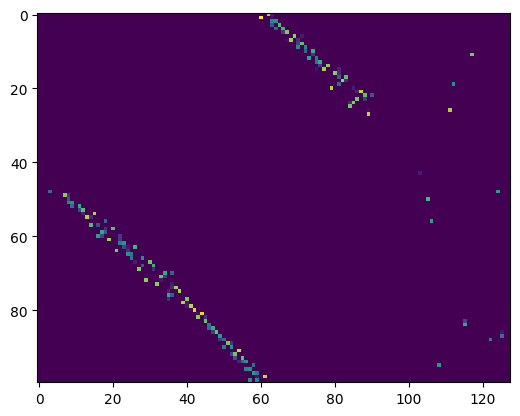

In [9]:
plt.imshow(T['T'])
plt.show()

In [10]:
coup = T['T']

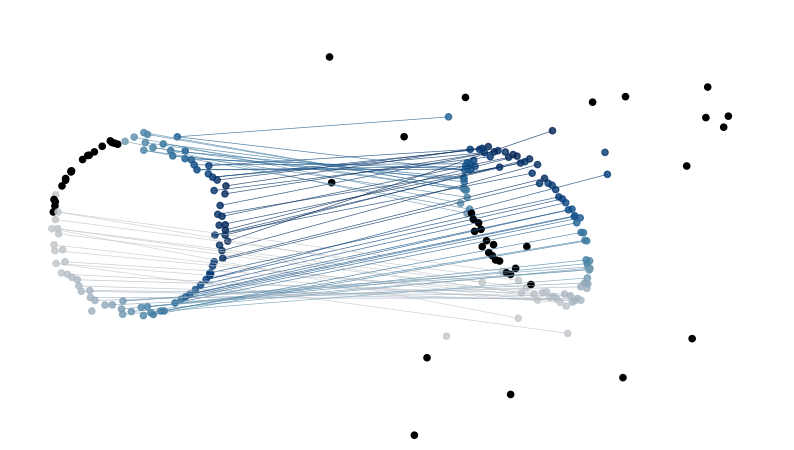

In [11]:
tol = 1e-5
percent_lines = .8

# Example inputs
pointcloud1 = template
n1 = len(pointcloud1)
pointcloud2 = shapes[shape_j] + np.array([9,0])
n2 = len(pointcloud2)

# Compute sums of rows and columns of 'coup'
row_sums = coup.sum(axis=1)
col_sums = coup.sum(axis=0)

# Prepare colors for the first point cloud
gradient = cm.Blues((pointcloud1[:, 0] - pointcloud1[:, 0].min()) / (pointcloud1[:, 0].max() - pointcloud1[:, 0].min()))
colors1 = np.zeros_like(gradient)  # Initialize colors array
for i in range(n1):
    colors1[i] = [0, 0, 0, 1] if row_sums[i] < tol else gradient[i]*.8

# Prepare colors for the second point cloud
colors2 = np.zeros((n2, 4))  # Initialize with black
matched_pairs = []
for j in range(n2):
    if col_sums[j] < tol:
        colors2[j] = [0, 0, 0, 1]  # Black
    else:
        i = np.argmax(coup[:, j])  # Find index of largest entry in column j
        colors2[j] = colors1[i]  # Match color with the first point cloud
        matched_pairs.append((i, j))

# Select 10% of matched pairs randomly for line drawing
num_lines = max(1, int(len(matched_pairs)*percent_lines))  # Ensure at least one line
sampled_pairs = np.random.choice(len(matched_pairs), size=num_lines, replace=False)

# Plot
plt.figure(figsize=(10, 8))

# Plot first point cloud
plt.scatter(pointcloud1[:, 0], pointcloud1[:, 1], c=colors1, s=20, label="Point Cloud 1")

# Plot second point cloud
plt.scatter(pointcloud2[:, 0], pointcloud2[:, 1], c=colors2, s=20, label="Point Cloud 2")

# Draw lines for sampled pairs
for idx in sampled_pairs:
    i, j = matched_pairs[idx]
    plt.plot(
        [pointcloud1[i, 0], pointcloud2[j, 0]],
        [pointcloud1[i, 1], pointcloud2[j, 1]],
        color=colors1[i],
        linewidth=0.5,
    )

# Customize and display
plt.xlim([-3, 15])
plt.ylim([-5, 5])
plt.gca().set_aspect('equal', adjustable='box')
# plt.xlabel("X-axis")
# plt.ylabel("Y-axis")
# plt.title("Point Cloud Correspondences")
# plt.legend()
plt.xticks([])  # Remove x-axis ticks and labels
plt.yticks([])  # Remove y-axis ticks and labels
plt.axis('off')
plt.show()

In [12]:
_, log = ot.gromov.gromov_wasserstein2(template_dist_mat,dist_mats[shape_j],template_distribution,distributions[shape_j], log = True)
coup = log['T']

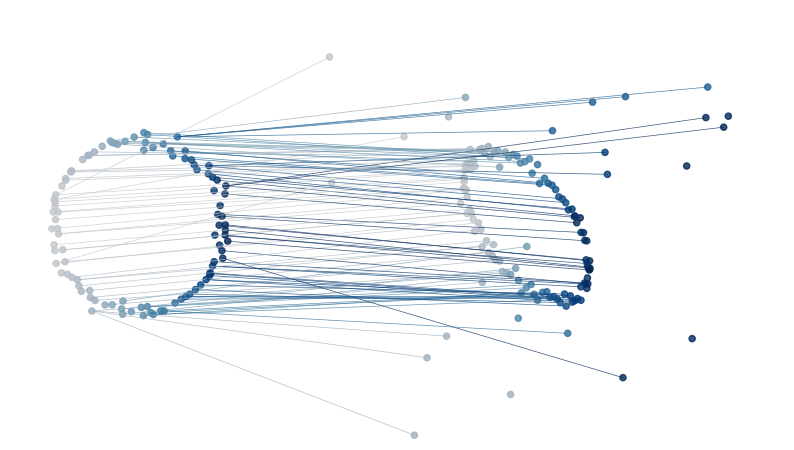

In [13]:
tol = 1e-5
percent_lines = .8

# Example inputs
pointcloud1 = template
n1 = len(pointcloud1)
pointcloud2 = shapes[shape_j] + np.array([9,0])
n2 = len(pointcloud2)

# Compute sums of rows and columns of 'coup'
row_sums = coup.sum(axis=1)
col_sums = coup.sum(axis=0)

# Prepare colors for the first point cloud
gradient = cm.Blues((pointcloud1[:, 0] - pointcloud1[:, 0].min()) / (pointcloud1[:, 0].max() - pointcloud1[:, 0].min()))
colors1 = np.zeros_like(gradient)  # Initialize colors array
for i in range(n1):
    colors1[i] = [0, 0, 0, 1] if row_sums[i] < tol else gradient[i]*.8

# Prepare colors for the second point cloud
colors2 = np.zeros((n2, 4))  # Initialize with black
matched_pairs = []
for j in range(n2):
    if col_sums[j] < tol:
        colors2[j] = [0, 0, 0, 1]  # Black
    else:
        i = np.argmax(coup[:, j])  # Find index of largest entry in column j
        colors2[j] = colors1[i]  # Match color with the first point cloud
        matched_pairs.append((i, j))

# Select 10% of matched pairs randomly for line drawing
num_lines = max(1, int(len(matched_pairs)*percent_lines))  # Ensure at least one line
sampled_pairs = np.random.choice(len(matched_pairs), size=num_lines, replace=False)

# Plot
plt.figure(figsize=(10, 8))

# Plot first point cloud
plt.scatter(pointcloud1[:, 0], pointcloud1[:, 1], c=colors1, s=20, label="Point Cloud 1")

# Plot second point cloud
plt.scatter(pointcloud2[:, 0], pointcloud2[:, 1], c=colors2, s=20, label="Point Cloud 2")

# Draw lines for sampled pairs
for idx in sampled_pairs:
    i, j = matched_pairs[idx]
    plt.plot(
        [pointcloud1[i, 0], pointcloud2[j, 0]],
        [pointcloud1[i, 1], pointcloud2[j, 1]],
        color=colors1[i],
        linewidth=0.5,
    )

# Customize and display
plt.xlim([-3, 15])
plt.ylim([-5, 5])
plt.gca().set_aspect('equal', adjustable='box')
# plt.xlabel("X-axis")
# plt.ylabel("Y-axis")
# plt.title("Point Cloud Correspondences")
# plt.legend()
plt.xticks([])  # Remove x-axis ticks and labels
plt.yticks([])  # Remove y-axis ticks and labels
plt.axis('off')
plt.show()

### Pairwise Distance Matrices

Let's create a bigger dataset to do the pairwise distance matrix.

In [14]:
num_shapes = 20
num_points = 100
labels = [0]*num_shapes + [1]*num_shapes
SNR_range = [0.05,3]
circle_radius = 2
ellipse_radii = [1,2]
outlier_bounds = [-5,5]
noise_level = 0.1


SNRs = np.linspace(SNR_range[0],SNR_range[1],num_shapes)
shapes = []

thetas = np.linspace(0,2*np.pi,num_points)
circle_points = circle_radius*np.array([np.cos(thetas),np.sin(thetas)])
ellipse_points = np.array([ellipse_radii[0]*np.cos(thetas),ellipse_radii[1]*np.sin(thetas)])

for SNR in SNRs:
    # Circles
    perturbed_points = (circle_points + np.random.normal(0, noise_level, num_points)).T
    num_random_points = int(SNR*num_points)
    if num_random_points == 0:
        noisy_points = perturbed_points
    else:
        random_points = np.random.uniform(outlier_bounds[0], outlier_bounds[1], (num_random_points, 2))
        noisy_points = np.vstack((perturbed_points, random_points))
    shapes.append(noisy_points)
    
for SNR in SNRs:
    # Ellipses
    perturbed_points = (ellipse_points + np.random.normal(0, noise_level, num_points)).T
    ## Add a rotation
    angle = np.random.uniform(0, 2 * np.pi)

    # Create the 2D rotation matrix
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],[np.sin(angle),  np.cos(angle)]])
    perturbed_points = perturbed_points@rotation_matrix
    
    
    num_random_points = int(SNR*num_points)
    if num_random_points == 0:
        noisy_points = perturbed_points
    else:
        random_points = np.random.uniform(outlier_bounds[0], outlier_bounds[1], (num_random_points, 2))
        noisy_points = np.vstack((perturbed_points, random_points))
    shapes.append(noisy_points)

In [15]:
dist_mats = [euclidean_distances(x) for x in shapes]

radius = 2

distributions = [density_based_weighting(dist_mat,radius = radius) for dist_mat in dist_mats]

Computing Gromov-Wasserstein distances:

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


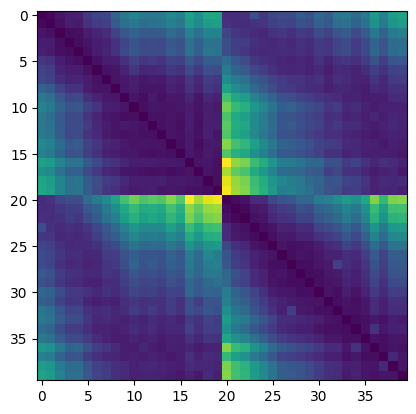

In [16]:
GW_dists = np.zeros([len(dist_mats),len(dist_mats)])

for i in range(len(dist_mats)):
    for j in range(i+1,len(dist_mats)):
        GW_dists[i,j] = ot.gromov_wasserstein2(dist_mats[i],dist_mats[j],distributions[i],distributions[j],'square_loss')
    print(i)  

GW_dists += GW_dists.T

plt.imshow(GW_dists)
plt.show()

Computing Robust Gromov-Wasserstein distances:

In [ ]:
k = 1

RGW_dists = np.zeros([len(dist_mats),len(dist_mats)])

for i in range(len(dist_mats)):
    for j in range(i+1,len(dist_mats)):
        m, dist, T = robust_mGW(dist_mats[i],dist_mats[j],distributions[i],distributions[j], k = k)
        RGW_dists[i,j] = m
    print(i)  

RGW_dists += RGW_dists.T

plt.imshow(RGW_dists)
plt.show()

0
1
2
3
4
5
6


/opt/anaconda3/envs/MultiscaleGW/lib/python3.12/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


7
8
9
10
11
12
13
14


Now we can visualize the clustering for these distance matrices.

In [ ]:
from sklearn.manifold import MDS

In [ ]:
embedding = MDS(n_components=2, normalized_stress='auto',dissimilarity = 'precomputed')
X_transformed = embedding.fit_transform(GW_dists)

plt.scatter(X_transformed[:,0],X_transformed[:,1],c = labels)
plt.title('MDS for Gromov-Wasserstein distances')
plt.show()

In [ ]:
embedding = MDS(n_components=2, normalized_stress='auto',dissimilarity = 'precomputed')
X_transformed = embedding.fit_transform(RGW_dists)

plt.scatter(X_transformed[:,0],X_transformed[:,1],c = labels)
plt.title('MDS for Robust Gromov-Wasserstein distances')
plt.show()

We quantify the clustering with k-NN matching scores.

In [ ]:
def k_NN(k,dist_mat,classes):
    # k = number of points for kNN classification; INTEGER
    # dist_mat = full distance matrix for all classes; NP ARRAY
    # classes = class labels, in same order as the rows of the matrix; LIST
    
    sorted_dist_mat = np.argsort(dist_mat,axis = 1)
    np_classes = np.array(classes)
    
    classification_successes = 0
    
    for i in range(len(dist_mat)):
        
        if np.sum(np_classes[sorted_dist_mat[i,1:k+1]] == classes[i])/k > 0.5:
            classification_successes += 1
            
    classification_rate = classification_successes/len(dist_mat)
    
    return classification_rate

In [ ]:
GW_kNN = []

for k in range(1,35):
    GW_kNN.append(k_NN(k,GW_dists,labels))

In [ ]:
RGW_kNN = []
ks = list(range(1,35))

for k in range(1,35):
    RGW_kNN.append(k_NN(k,RGW_dists,labels))

We now plot kNN scores for various values of $k$.

In [ ]:
plt.figure(figsize = (10,8))
plt.plot(ks,GW_kNN,label='Gromov-Wasserstein')
plt.plot(ks,RGW_kNN, label = 'Robust Gromov-Wasserstein')
plt.legend(fontsize = 20)
plt.title('kNN Scores for Circles and Ellipses',fontsize = 20)
plt.show()

Finally, we visualize the clustering in an alternative way, via dendrograms.

In [ ]:
import scipy.cluster.hierarchy as sch
from matplotlib.collections import LineCollection

# Assuming GW_dists is your distance matrix (numpy array) and labels is your list of classes
# Example setup for labels (replace with your actual data):
# labels = ['class1', 'class2', 'class1', 'class2', ...]

# Assign unique colors to each class
unique_classes = list(set(labels))
class_to_color = {cls: plt.cm.tab10(i / len(unique_classes)) for i, cls in enumerate(unique_classes)}
leaf_colors = [class_to_color[label] for label in labels]

# Perform single linkage hierarchical clustering
linkage_matrix = sch.linkage(GW_dists, method='ward')

# Create the dendrogram
fig, ax = plt.subplots(figsize=(10, 8))

# Define a custom leaf color function
def leaf_color_func(index):
    return leaf_colors[index]

new_labels = ['C']*num_shapes + ['E']*num_shapes

# Generate the dendrogram with the custom leaf color function
dendro = sch.dendrogram(
    linkage_matrix,
    labels=labels,
    leaf_rotation=0,
    leaf_font_size=100,
    color_threshold=0,  # Disables the coloring of branches
    leaf_label_func=lambda x: new_labels[x],
)

# Color the leaf text according to the class
ax.tick_params(axis='x', which='major', labelsize=8)
for label in ax.get_xmajorticklabels():
    label_text = label.get_text()
    label_class = labels[int(label_text)] if label_text.isdigit() else label_text
    label.set_fontsize(15)
    if label_text == 'C':
        label.set_color('blue')
    else:
        label.set_color('red')

plt.title("Gromov-Wasserstein Dendrogram",fontsize = 20)
# plt.xlabel("Classes")
plt.yticks([])
plt.tight_layout()
plt.show()


In [ ]:
import scipy.cluster.hierarchy as sch
from matplotlib.collections import LineCollection

# Assuming GW_dists is your distance matrix (numpy array) and labels is your list of classes
# Example setup for labels (replace with your actual data):
# labels = ['class1', 'class2', 'class1', 'class2', ...]

# Assign unique colors to each class
unique_classes = list(set(labels))
class_to_color = {cls: plt.cm.tab10(i / len(unique_classes)) for i, cls in enumerate(unique_classes)}
leaf_colors = [class_to_color[label] for label in labels]

# Perform single linkage hierarchical clustering
linkage_matrix = sch.linkage(RGW_dists, method='ward')

# Create the dendrogram
fig, ax = plt.subplots(figsize=(10, 8))

# Define a custom leaf color function
def leaf_color_func(index):
    return leaf_colors[index]

new_labels = ['C']*num_shapes + ['E']*num_shapes

# Generate the dendrogram with the custom leaf color function
dendro = sch.dendrogram(
    linkage_matrix,
    labels=labels,
    leaf_rotation=0,
    leaf_font_size=100,
    color_threshold=0,  # Disables the coloring of branches
    leaf_label_func=lambda x: new_labels[x],
)

# Color the leaf text according to the class
ax.tick_params(axis='x', which='major', labelsize=8)
for label in ax.get_xmajorticklabels():
    label_text = label.get_text()
    label_class = labels[int(label_text)] if label_text.isdigit() else label_text
    label.set_fontsize(15)
    if label_text == 'C':
        label.set_color('blue')
    else:
        label.set_color('red')

plt.title("Robust Gromov-Wasserstein Dendrogram", fontsize = 20)
# plt.xlabel("Classes")
plt.yticks([])
plt.tight_layout()
plt.show()
